<a href="https://colab.research.google.com/github/DevikaRelangi-glitch/Worlflow1/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================
# 1. Setup & Installation
# =====================================
!pip install kaggle shap xgboost imbalanced-learn seaborn matplotlib

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from imblearn.over_sampling import SMOTE

In [ ]:
# =====================================
# 2. Kaggle API Authentication & Dataset Download
# =====================================
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d dhanushnarayananr/credit-card-fraud
!unzip credit-card-fraud.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud
License(s): CC0-1.0
credit-card-fraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  credit-card-fraud.zip
replace card_transdata.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
# =====================================
# 3. Load Dataset
# =====================================
df = pd.read_csv("card_transdata.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (1000000, 8)
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0    0.0  
4              0.0           1.0    

In [ ]:
# =====================================
# 4 Data Quality Checks
# =====================================
print("\nMissing values per column:\n", df.isnull().sum())
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("After dropping missing values, new shape:", df.shape)
else:
    print("No missing values found.")

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("After dropping duplicates, new shape:", df.shape)
else:
    print("No duplicate rows found.")


Missing values per column:
 distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64
No missing values found.
Number of duplicate rows: 0
No duplicate rows found.


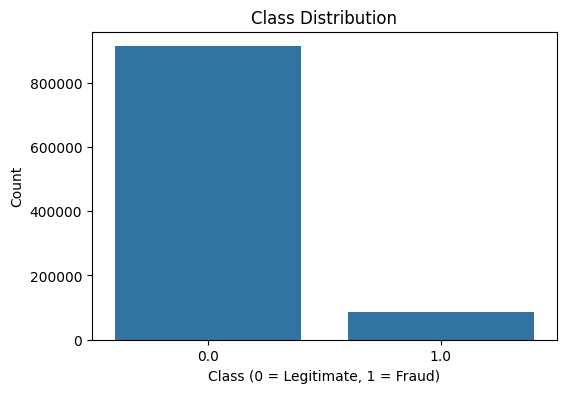

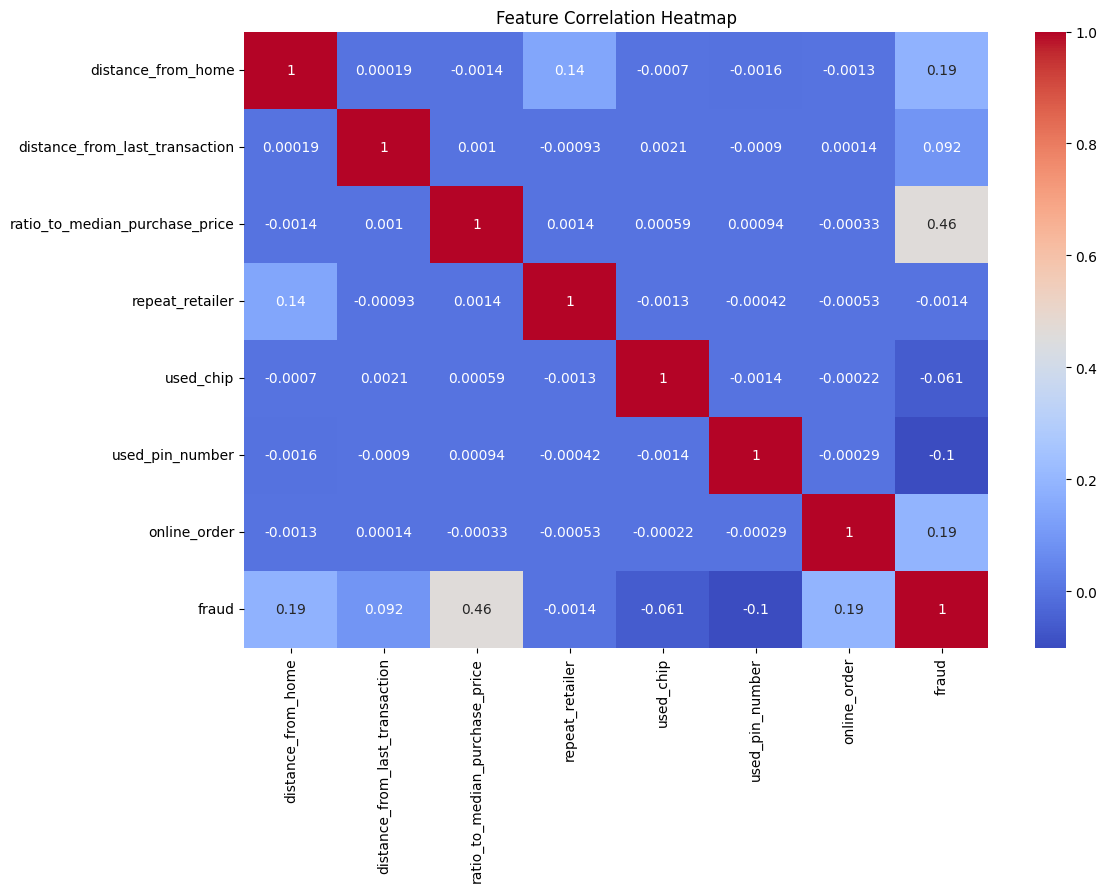

In [ ]:
# =====================================
# 5 Exploratory Data Analysis (EDA)
# =====================================

plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title('Class Distribution')
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Count")
plt.savefig('figure4.1_class_distribution.png')
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig('figure4.2_correlation_heatmap.png')
plt.show()


In [ ]:
# =====================================
# 6 Data Preparation
# =====================================
X = df.drop('fraud', axis=1)
y = df['fraud']

# Train/Test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training set size:", X_train.shape, "Testing set size:", X_test.shape)


Training set size: (700000, 7) Testing set size: (300000, 7)


In [ ]:
# =====================================
# 7 Pipeline 1 - Original Imbalanced Data
# =====================================
model_imbalanced = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
model_imbalanced.fit(X_train, y_train)

y_pred_imb = model_imbalanced.predict(X_test)
print("\nPerformance on Original Imbalanced Data:")

# Get classification report as a dictionary
report_dict_imb = classification_report(y_test, y_pred_imb, output_dict=True)
# Convert to DataFrame for better display
report_df_imb = pd.DataFrame(report_dict_imb).transpose()

# Rename the index for clarity
report_df_imb = report_df_imb.rename(index={'0.0': 'Legitimate', '1.0': 'Fraud'})

display(report_df_imb)

roc_auc_imb = roc_auc_score(y_test, model_imbalanced.predict_proba(X_test)[:,1])
print(f"\nROC-AUC: {roc_auc_imb}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:56:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performance on Original Imbalanced Data:


,precision,recall,f1-score,support
Legitimate,0.999160,0.999010,0.999085,273779.00000
Fraud,0.989681,0.991228,0.990454,26221.00000
accuracy,0.998330,0.998330,0.998330,0.99833
macro avg,0.994420,0.995119,0.994770,300000.00000
weighted avg,0.998331,0.998330,0.998331,300000.00000



ROC-AUC: 0.999973460524893


In [ ]:
# =====================================
# 7 Pipeline 2 - SMOTE Balanced Data
# =====================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_sm.shape, "Fraud %:", sum(y_train_sm)/len(y_train_sm))

model_smote = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
model_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = model_smote.predict(X_test)
print("\nPerformance on SMOTE Balanced Data:")

# Get classification report as a dictionary
report_dict_sm = classification_report(y_test, y_pred_sm, output_dict=True)
# Convert to DataFrame for better display
report_df_sm = pd.DataFrame(report_dict_sm).transpose()

# Rename the index for clarity
report_df_sm = report_df_sm.rename(index={'0.0': 'Legitimate', '1.0': 'Fraud'})

display(report_df_sm)

print("ROC-AUC:", roc_auc_score(y_test, model_smote.predict_proba(X_test)[:,1]))

After SMOTE: (1277636, 7) Fraud %: 0.5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:57:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performance on SMOTE Balanced Data:


,precision,recall,f1-score,support
Legitimate,0.999652,0.997801,0.998726,273779.000000
Fraud,0.977477,0.996377,0.986836,26221.000000
accuracy,0.997677,0.997677,0.997677,0.997677
macro avg,0.988565,0.997089,0.992781,300000.000000
weighted avg,0.997714,0.997677,0.997687,300000.000000


ROC-AUC: 0.9999778752154123



Generating SHAP Summary Plots...


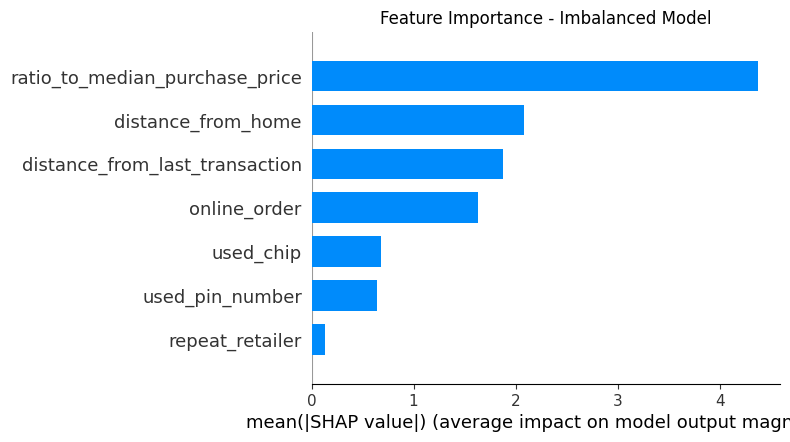

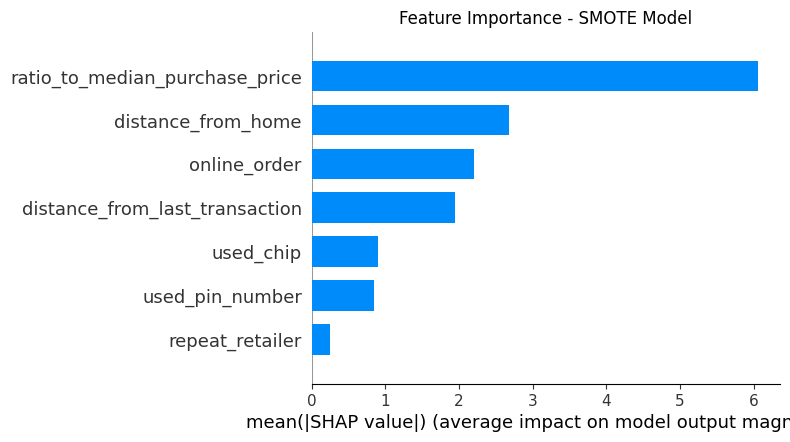

In [ ]:
# =====================================
# 8 SHAP Explainability
# =====================================
explainer_imb = shap.TreeExplainer(model_imbalanced)
shap_values_imb = explainer_imb.shap_values(X_test)

explainer_sm = shap.TreeExplainer(model_smote)
shap_values_sm = explainer_sm.shap_values(X_test)

print("\nGenerating SHAP Summary Plots...")
shap.summary_plot(shap_values_imb, X_test, plot_type="bar", show=False)
plt.title("Feature Importance - Imbalanced Model")
plt.savefig('figure4.4_Pipeline1_SHAP_Summary.png')
plt.show()

shap.summary_plot(shap_values_sm, X_test, plot_type="bar", show=False)
plt.title("Feature Importance - SMOTE Model")
plt.savefig('figure4.5_Pipeline2_SHAP_Summary.png')
plt.show()
